# Track training (local)

Reads the JSONL metrics sidecars that `train_pipeline/train_head.py` writes next to its `--output` (e.g. `trained_heads/sweep/refdelta/mlp_hw500/model.metrics.jsonl`) and plots per-trait train/val curves — no wandb cloud connection needed.

The next cell **discovers every run** under `SWEEP_ROOT` into a `RUNS` table with parsed attributes:

- **variant** — `absolute` (plain `FPSumHeadModel`) vs `refdelta` (reference-subtracted)
- **head** — `mlp` vs `linear`
- **tag** / **half_window** / **snponly** — the cache the head was trained on

Use `select_runs(RUNS, variant=..., head=..., ...)` to filter to the runs you care about, and set `COLOR_BY` to group them visually — runs sharing that attribute's value share a color. Each trait gets a row of (MSE, PCC) panels, with **train dashed** and **val a bold solid line in the same color**.

Each JSONL line is one logged row: `train/*` on a step cadence, `val/*` once per epoch. Run the **live follow** cell to watch runs as they train.

In [17]:
import json
import re
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# Root of the run_sweep.sh outputs. Each run writes a JSONL metrics sidecar at
#   trained_heads/sweep/<variant>/<head>_<tag>/model.metrics.jsonl
# Point SWEEP_ROOT elsewhere (or pass root= to discover_runs) for other dirs.
SWEEP_ROOT = Path("../trained_heads/head_sweep")

# Traits to plot, one row of (MSE, PCC) panels each.
EVAL_TRAITS = [
    "Alkali spreading value",
    "Amylose content",
    "Panicle number per plant",
    "Protein content",
    "Seed length",
    "Seed number per panicle",
]

_RUN_COLS = ["path", "variant", "head", "tag", "half_window", "snponly", "label"]


def parse_run(metrics_path):
    """Derive grouping attributes for one run from its metrics-sidecar path.

    Expected layout (run_sweep.sh):
        trained_heads/sweep/<variant>/<head>_<tag>/model.metrics.jsonl
    <variant> in {absolute, refdelta}, <head> in {linear, mlp}, <tag> like
    hw500 / hw500_snponly. Falls back for the older flat layout (no <variant>
    dir; 'refdelta' inferred from the path) so old runs still load.
    """
    p = Path(metrics_path)
    run_dir = p.parent                       # <head>_<tag>
    variant_dir = run_dir.parent.name        # <variant> in the new layout

    if variant_dir in ("absolute", "refdelta"):
        variant = variant_dir
    else:
        variant = "refdelta" if "refdelta" in str(p) else "absolute"

    name = run_dir.name                       # e.g. mlp_hw500_snponly
    head = next((h for h in ("linear", "mlp") if name.startswith(h)), "?")
    tag = name.split("_", 1)[1] if "_" in name else name
    snponly = tag.endswith("snponly")
    m = re.search(r"hw(\d+)", tag)
    half_window = int(m.group(1)) if m else None

    return {
        "path": p,
        "variant": variant,
        "head": head,
        "tag": tag,
        "half_window": half_window,
        "snponly": snponly,
        "label": f"{variant}·{head}·{tag}",
    }


def discover_runs(root=SWEEP_ROOT):
    """All metrics sidecars under `root`, one parsed row per run."""
    paths = sorted(Path(root).glob("**/model.metrics.jsonl"))
    return pd.DataFrame([parse_run(p) for p in paths], columns=_RUN_COLS)


def select_runs(runs, *, variant=None, head=None, tag=None,
                half_window=None, snponly=None):
    """Filter the run registry; each constraint takes a scalar or a list/set.

        select_runs(RUNS, variant="refdelta", head="mlp")
        select_runs(RUNS, head=["linear", "mlp"], half_window=500)
    """
    df = runs
    for col, val in [("variant", variant), ("head", head), ("tag", tag),
                     ("half_window", half_window), ("snponly", snponly)]:
        if val is None:
            continue
        allowed = val if isinstance(val, (list, tuple, set)) else [val]
        df = df[df[col].isin(allowed)]
    return df.reset_index(drop=True)


def load_metrics(path):
    """Read a JSONL sidecar into a DataFrame, tolerating a half-written final
    line (the trainer may be mid-flush when we read)."""
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue  # partial last line during a live write
    return pd.DataFrame(rows)


def load_selected(runs):
    """Load a (filtered) runs DataFrame into an ordered
    {label: {**attrs, "df": DataFrame}} dict for plotting/summaries."""
    out = {}
    for r in runs.itertuples(index=False):
        info = dict(zip(_RUN_COLS, r))
        info["df"] = load_metrics(info["path"])
        out[info["label"]] = info
    return out


def _color_map(loaded, color_by):
    """Stable color per distinct value of the `color_by` attribute."""
    keys = list(dict.fromkeys(info[color_by] for info in loaded.values()))
    cmap = plt.get_cmap("tab10")
    return {k: cmap(i % 10) for i, k in enumerate(keys)}


def summary_table(loaded, traits, metric="pcc", split="val"):
    """Latest logged `split/<metric>/<trait>` per run x trait (DataFrame)."""
    cols = {}
    for label, info in loaded.items():
        df = info["df"]
        s = {}
        for trait in traits:
            col = f"{split}/{metric}/{trait}"
            if col in df.columns and df[col].notna().any():
                s[trait] = df[col].dropna().iloc[-1]
        if 'val/mean_pcc' in df.columns:
            s['val/mean_pcc'] = df['val/mean_pcc'].dropna().iloc[-1]
        cols[label] = s
    return pd.DataFrame(cols)


def group_summary(loaded, traits, by="variant", metric="pcc", split="val"):
    """Mean of the latest `split/<metric>` across runs, grouped by attribute(s)
    `by` (str or list). Good for 'refdelta vs absolute' or 'mlp vs linear'."""
    tbl = summary_table(loaded, traits, metric=metric, split=split).T  # runs x traits
    keys = [by] if isinstance(by, str) else list(by)
    tbl[keys] = [[loaded[label][k] for k in keys] for label in tbl.index]
    return tbl.groupby(keys).mean(numeric_only=True)


def plot_traits(loaded, traits, color_by="label", show_train=True):
    """One row of (MSE, PCC) panels per trait. Color encodes `color_by` (e.g.
    'label', 'variant', 'head', 'tag'); val is a bold solid line, train dashed.
    Runs sharing a `color_by` value share a color — that's the grouping."""
    if not loaded:
        print("no runs selected — adjust select_runs(...) above.")
        return
    n = len(traits)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n), squeeze=False)
    colors = _color_map(loaded, color_by)
    for row, trait in enumerate(traits):
        for ax, metric in [(axes[row][0], "mse"), (axes[row][1], "pcc")]:
            seen = set()
            for info in loaded.values():
                df = info["df"]
                color = colors[info[color_by]]
                splits = [("val", "-", 2.5, 1.0)]
                if show_train:
                    splits.append(("train", "--", 1.5, 0.6))
                for split, ls, lw, alpha in splits:
                    col = f"{split}/{metric}/{trait}"
                    if col not in df.columns:
                        continue
                    sub = df.dropna(subset=[col, "step"])
                    if not len(sub):
                        continue
                    leg = f"{info[color_by]} · {split}"
                    lbl = leg if leg not in seen else None
                    seen.add(leg)
                    ax.plot(sub["step"], sub[col], linestyle=ls, linewidth=lw,
                            alpha=alpha, color=color, label=lbl)
            ax.set(xlabel="step", ylabel=metric, title=f"{trait} — {metric}")
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

RUNS = discover_runs()
print(f"Discovered {len(RUNS)} runs under {SWEEP_ROOT}:")
RUNS[["label", "variant", "head", "tag", "half_window", "snponly"]]

Discovered 15 runs under ../trained_heads/head_sweep:


,label,variant,head,tag,half_window,snponly
0,absolute·?·carbon500m_hw500__absolute_linear_m...,absolute,?,carbon500m_hw500__absolute_linear_mean_ws0_lr1...,500,False
1,absolute·?·carbon500m_hw500__absolute_linear_m...,absolute,?,carbon500m_hw500__absolute_linear_mean_ws1_lr1...,500,False
2,absolute·?·carbon500m_hw500__absolute_linear_s...,absolute,?,carbon500m_hw500__absolute_linear_sum_ws1_lr1e...,500,False
3,absolute·?·carbon500m_hw500__absolute_mlp_mean...,absolute,?,carbon500m_hw500__absolute_mlp_mean_ws0_lr1e-3...,500,False
4,absolute·?·carbon500m_hw500__absolute_mlp_mean...,absolute,?,carbon500m_hw500__absolute_mlp_mean_ws1_lr1e-3...,500,False
5,absolute·?·carbon500m_hw500__absolute_mlp_sum_...,absolute,?,carbon500m_hw500__absolute_mlp_sum_ws1_lr1e-3_...,500,False
6,absolute·?·carbon500m_hw500__centered_linear_m...,absolute,?,carbon500m_hw500__centered_linear_mean_ws0_lr1...,500,False
7,absolute·?·carbon500m_hw500__centered_linear_m...,absolute,?,carbon500m_hw500__centered_linear_mean_ws1_lr1...,500,False
8,absolute·?·carbon500m_hw500__centered_linear_s...,absolute,?,carbon500m_hw500__centered_linear_sum_ws1_lr1e...,500,False
9,absolute·?·carbon500m_hw500__centered_mlp_mean...,absolute,?,carbon500m_hw500__centered_mlp_mean_ws0_lr1e-3...,500,False


## Select & group

`RUNS` (above) is the registry of every discovered run. Filter it with `select_runs(...)` — by `variant` (`absolute` vs `refdelta`), `head` (`mlp` vs `linear`), `tag`, `half_window`, or `snponly` — then `load_selected` reads the chosen sidecars into `loaded`. `COLOR_BY` controls the visual grouping in the plots and the `group_summary` below (color is shared across runs with the same value). Re-run this cell after changing a filter.

In [18]:
# ── Pick which runs to look at ────────────────────────────────────────────────
# Each filter takes a scalar or a list; None means "no constraint". Examples:
#   select_runs(RUNS, variant="refdelta")            # only ref-subtracted heads
#   select_runs(RUNS, head="mlp")                    # only MLP heads
#   select_runs(RUNS, variant="absolute", head="linear", half_window=500)
SELECTION = select_runs(
    RUNS,
    variant=None,     # "absolute" | "refdelta" | ["absolute", "refdelta"] | None
    head=None,        # "mlp" | "linear" | None
    tag=None,         # e.g. "hw500" or ["hw500", "hw500_snponly"]
    half_window=None,  # e.g. 500 or [500, 1000]
    snponly=None,     # True | False | None
)

# How to color/group the curves: "variant", "head", "tag", or "label" (per-run).
COLOR_BY = "variant"

loaded = load_selected(SELECTION)
print(f"{len(loaded)} runs selected (color_by={COLOR_BY!r}):")
SELECTION[["label", "variant", "head", "tag", "half_window", "snponly"]]

15 runs selected (color_by='variant'):


,label,variant,head,tag,half_window,snponly
0,absolute·?·carbon500m_hw500__absolute_linear_m...,absolute,?,carbon500m_hw500__absolute_linear_mean_ws0_lr1...,500,False
1,absolute·?·carbon500m_hw500__absolute_linear_m...,absolute,?,carbon500m_hw500__absolute_linear_mean_ws1_lr1...,500,False
2,absolute·?·carbon500m_hw500__absolute_linear_s...,absolute,?,carbon500m_hw500__absolute_linear_sum_ws1_lr1e...,500,False
3,absolute·?·carbon500m_hw500__absolute_mlp_mean...,absolute,?,carbon500m_hw500__absolute_mlp_mean_ws0_lr1e-3...,500,False
4,absolute·?·carbon500m_hw500__absolute_mlp_mean...,absolute,?,carbon500m_hw500__absolute_mlp_mean_ws1_lr1e-3...,500,False
5,absolute·?·carbon500m_hw500__absolute_mlp_sum_...,absolute,?,carbon500m_hw500__absolute_mlp_sum_ws1_lr1e-3_...,500,False
6,absolute·?·carbon500m_hw500__centered_linear_m...,absolute,?,carbon500m_hw500__centered_linear_mean_ws0_lr1...,500,False
7,absolute·?·carbon500m_hw500__centered_linear_m...,absolute,?,carbon500m_hw500__centered_linear_mean_ws1_lr1...,500,False
8,absolute·?·carbon500m_hw500__centered_linear_s...,absolute,?,carbon500m_hw500__centered_linear_sum_ws1_lr1e...,500,False
9,absolute·?·carbon500m_hw500__centered_mlp_mean...,absolute,?,carbon500m_hw500__centered_mlp_mean_ws0_lr1e-3...,500,False


## Static snapshot
Summaries and plots of whatever the **selected** runs have logged so far: a per-run table of the latest val PCC, the same means grouped by `COLOR_BY`, then the per-trait curves.

In [19]:
# Latest val PCC per selected run x trait.
print("latest val PCC (per run)")
display(summary_table(loaded, EVAL_TRAITS))

# Grouped mean — change `by` to compare e.g. "variant", "head", or ["variant", "head"].
print(f"\nmean latest val PCC grouped by {COLOR_BY!r}")
display(group_summary(loaded, EVAL_TRAITS, by=COLOR_BY))

latest val PCC (per run)


,absolute·?·carbon500m_hw500__absolute_linear_mean_ws0_lr1e-3_wd1e-4_ep15,absolute·?·carbon500m_hw500__absolute_linear_mean_ws1_lr1e-3_wd1e-4_ep15,absolute·?·carbon500m_hw500__absolute_linear_sum_ws1_lr1e-3_wd1e-4_ep15,absolute·?·carbon500m_hw500__absolute_mlp_mean_ws0_lr1e-3_wd1e-4_ep15,absolute·?·carbon500m_hw500__absolute_mlp_mean_ws1_lr1e-3_wd1e-4_ep15,absolute·?·carbon500m_hw500__absolute_mlp_sum_ws1_lr1e-3_wd1e-4_ep15,absolute·?·carbon500m_hw500__centered_linear_mean_ws0_lr1e-3_wd1e-4_ep15,absolute·?·carbon500m_hw500__centered_linear_mean_ws1_lr1e-3_wd1e-4_ep15,absolute·?·carbon500m_hw500__centered_linear_sum_ws1_lr1e-3_wd1e-4_ep15,absolute·?·carbon500m_hw500__centered_mlp_mean_ws0_lr1e-3_wd1e-4_ep15,absolute·?·carbon500m_hw500__centered_mlp_mean_ws1_lr1e-3_wd1e-4_ep15,absolute·?·carbon500m_hw500__centered_mlp_sum_ws1_lr1e-3_wd1e-4_ep15,refdelta·?·carbon500m_hw500__refdelta_linear_mean_ws0_lr1e-3_wd1e-4_ep15,refdelta·?·carbon500m_hw500__refdelta_linear_mean_ws1_lr1e-3_wd1e-4_ep15,refdelta·?·carbon500m_hw500__refdelta_linear_sum_ws1_lr1e-3_wd1e-4_ep15
Alkali spreading value,-0.170899,0.036187,0.514835,0.118881,-0.367293,0.550501,0.440396,0.034346,0.516657,0.173626,-0.267677,0.551770,NaN,NaN,NaN
Amylose content,-0.193475,0.465094,0.785815,-0.423290,0.547526,0.829174,0.514860,0.464970,0.785836,0.054542,-0.322785,0.826240,NaN,NaN,NaN
Panicle number per plant,-0.353630,-0.046806,0.790916,-0.246974,0.292627,0.775055,0.686322,-0.060294,0.792667,0.705433,0.295754,0.776387,NaN,NaN,NaN
Protein content,-0.249623,0.307048,0.409743,-0.208379,-0.343539,0.483274,0.132371,0.308164,0.407508,0.253846,0.076462,0.477347,NaN,NaN,NaN
Seed length,-0.269529,-0.214760,0.543813,-0.144610,-0.118450,0.648799,0.435460,-0.213221,0.545291,0.342692,-0.003775,0.638877,NaN,NaN,NaN
Seed number per panicle,-0.216456,-0.154354,0.372615,0.282097,-0.355142,0.359572,0.083783,-0.155716,0.370829,-0.315356,0.140149,0.366644,NaN,NaN,NaN
val/mean_pcc,-0.088308,0.172494,0.536651,0.011790,0.018449,0.588978,0.355896,0.171642,0.536233,0.217408,0.046002,0.587806,NaN,NaN,NaN



mean latest val PCC grouped by 'variant'


,Alkali spreading value,Amylose content,Panicle number per plant,Protein content,Seed length,Seed number per panicle,val/mean_pcc
variant,,,,,,,
absolute,0.177611,0.361209,0.367288,0.171185,0.182549,0.064889,0.26292
refdelta,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
d = next(iter(loaded.values()))
print([x for x in d['df'].columns if not (('pcc' in x) or ('mse' in x))])

['epoch', 'step']


absolute·?·carbon500m_hw500__absolute_linear_mean_ws0_lr1e-3_wd1e-4_ep15: 19 rows · steps 0-75
absolute·?·carbon500m_hw500__absolute_linear_mean_ws1_lr1e-3_wd1e-4_ep15: 19 rows · steps 0-75
absolute·?·carbon500m_hw500__absolute_linear_sum_ws1_lr1e-3_wd1e-4_ep15: 19 rows · steps 0-75
absolute·?·carbon500m_hw500__absolute_mlp_mean_ws0_lr1e-3_wd1e-4_ep15: 19 rows · steps 0-75
absolute·?·carbon500m_hw500__absolute_mlp_mean_ws1_lr1e-3_wd1e-4_ep15: 19 rows · steps 0-75
absolute·?·carbon500m_hw500__absolute_mlp_sum_ws1_lr1e-3_wd1e-4_ep15: 19 rows · steps 0-75
absolute·?·carbon500m_hw500__centered_linear_mean_ws0_lr1e-3_wd1e-4_ep15: 19 rows · steps 0-75
absolute·?·carbon500m_hw500__centered_linear_mean_ws1_lr1e-3_wd1e-4_ep15: 19 rows · steps 0-75
absolute·?·carbon500m_hw500__centered_linear_sum_ws1_lr1e-3_wd1e-4_ep15: 19 rows · steps 0-75
absolute·?·carbon500m_hw500__centered_mlp_mean_ws0_lr1e-3_wd1e-4_ep15: 19 rows · steps 0-75
absolute·?·carbon500m_hw500__centered_mlp_mean_ws1_lr1e-3_wd1e-4_

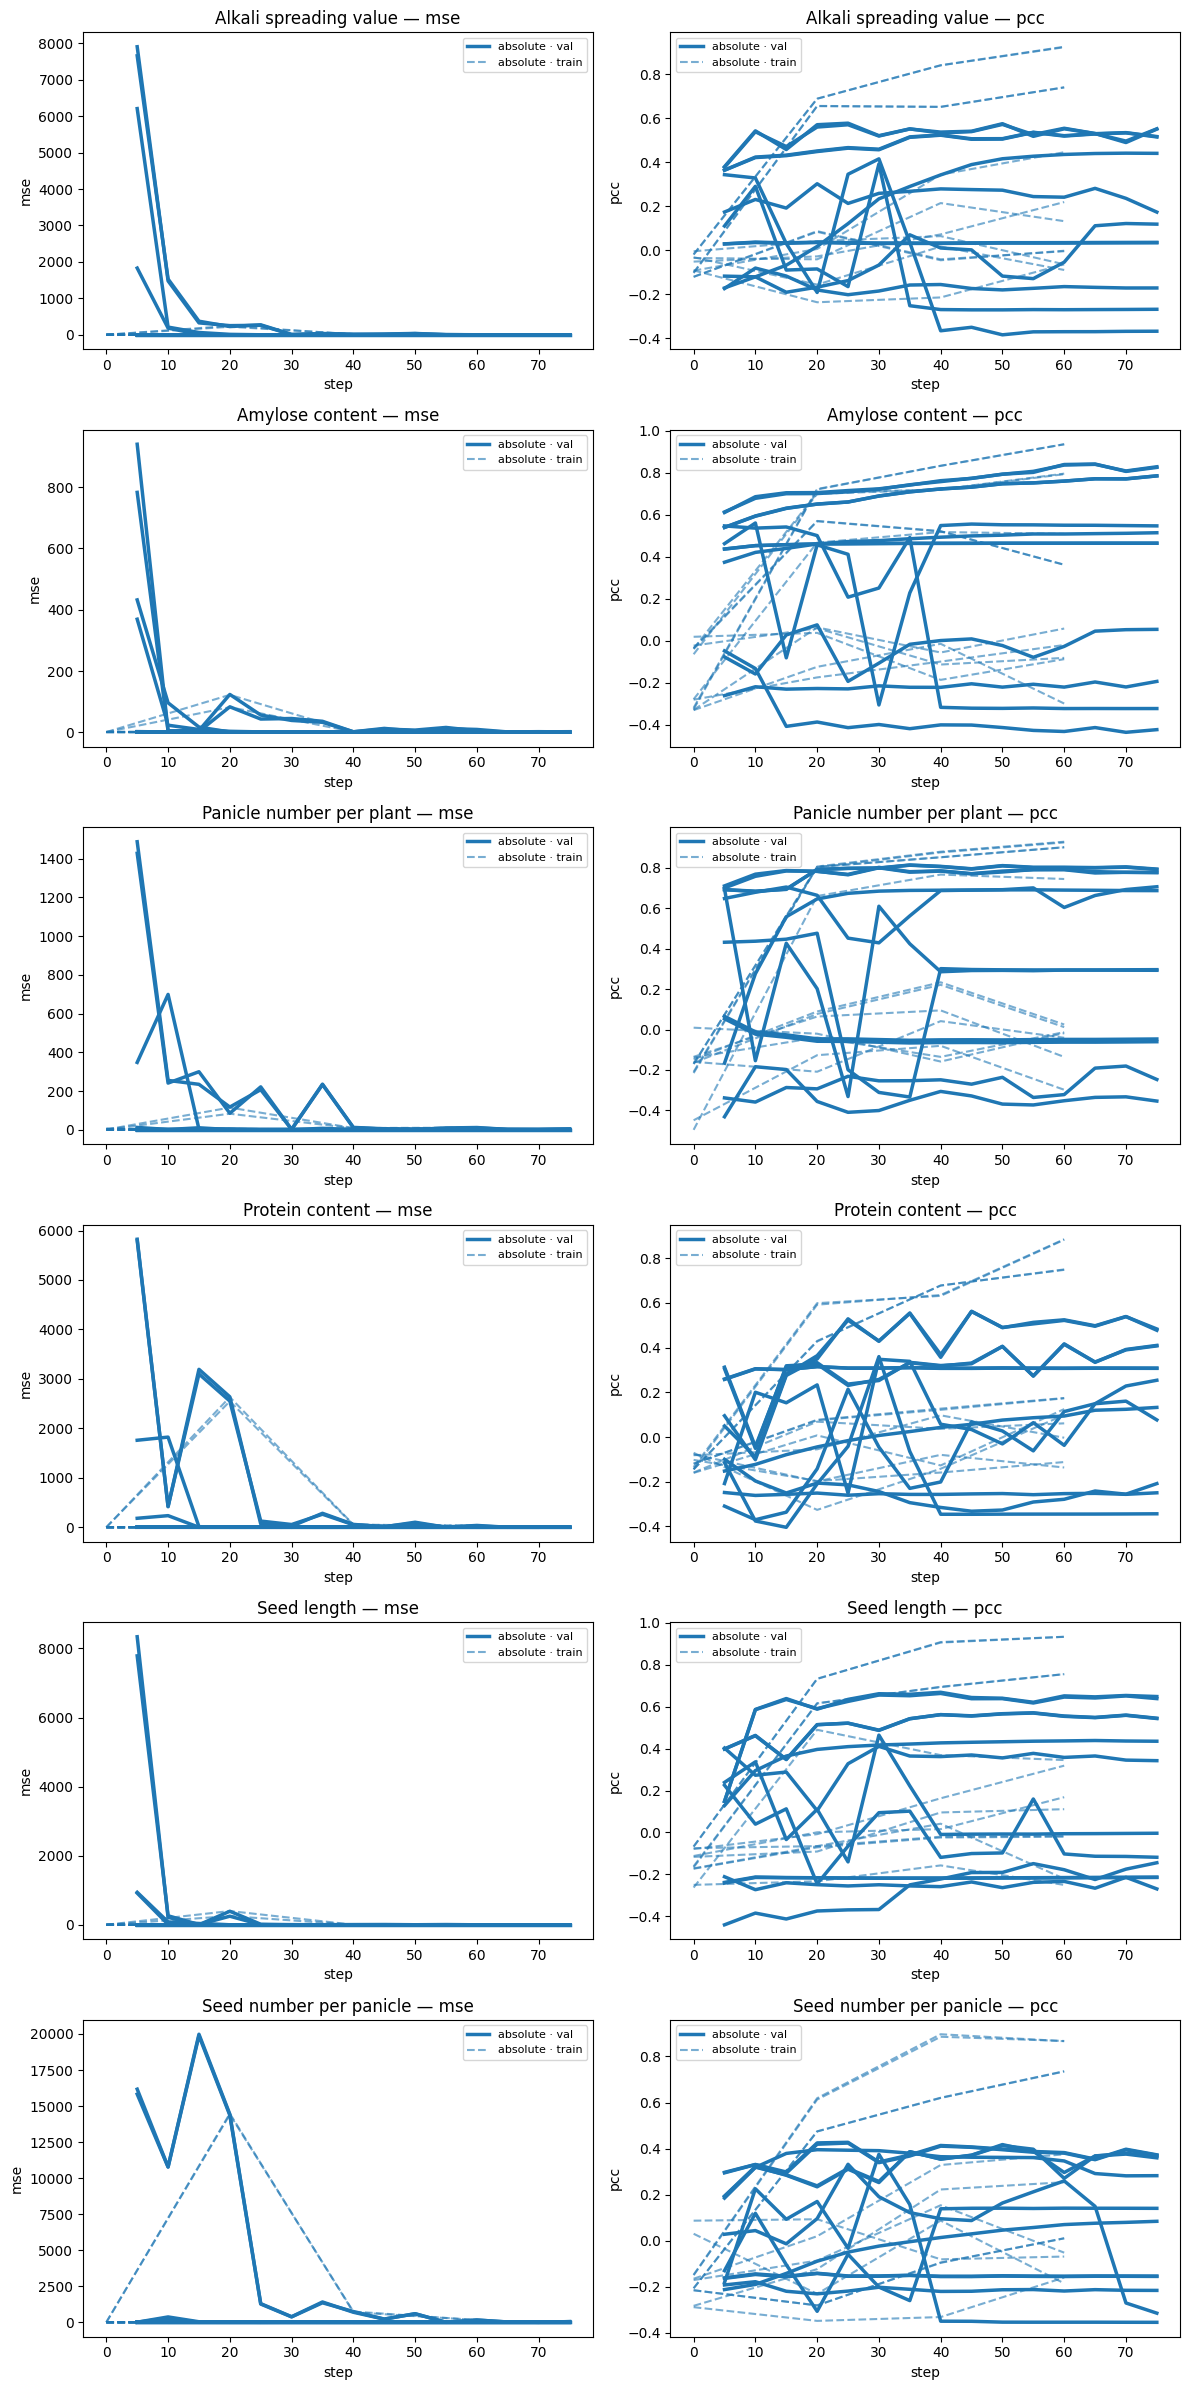

In [21]:
for label, info in loaded.items():
    df = info["df"]
    if len(df):
        print(f"{label}: {len(df)} rows · steps {int(df['step'].min())}-{int(df['step'].max())}")
plot_traits(loaded, EVAL_TRAITS, color_by=COLOR_BY)

## Live follow
Re-reads the file and redraws every few seconds. Interrupt the kernel (■ / `Ctrl-C`) to stop.

In [1]:
REFRESH_SEC = 5

# Re-applies the SAME filters as the selection cell each tick, re-discovering runs
# so newly-started runs in the sweep appear. Edit the kwargs here to match.
def reselect():
    return select_runs(discover_runs(), variant=None, head=None, tag=None,
                       half_window=None, snponly=None)

try:
    while True:
        loaded = load_selected(reselect())
        clear_output(wait=True)
        plot_traits(loaded, EVAL_TRAITS, color_by=COLOR_BY)
        last = max((int(info["df"]["step"].max())
                    for info in loaded.values() if len(info["df"])), default=None)
        print(f"{len(loaded)} runs · last step {last} · color_by={COLOR_BY} · "
              f"refreshing every {REFRESH_SEC}s (interrupt to stop)")
        time.sleep(REFRESH_SEC)
except KeyboardInterrupt:
    print("stopped following")

NameError: name 'load_selected' is not defined